C:\Users\Paule\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


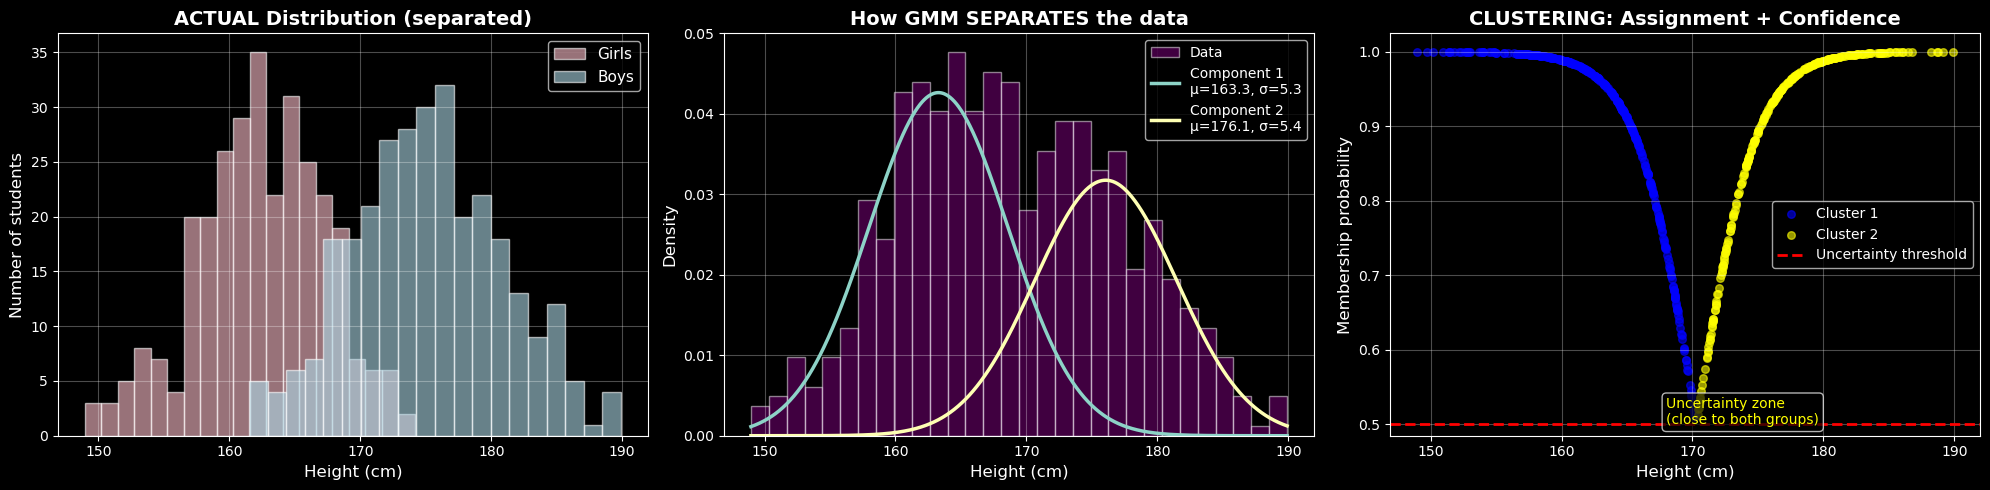

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
plt.style.use('dark_background')

def plot_height_distribution_with_gmm(girls_heights, boys_heights):
    all_heights = np.concatenate([girls_heights, boys_heights])
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    ax1, ax2, ax3 = axes

    # Graph 1: Separate distributions
    ax1.hist(girls_heights, bins=20, alpha=0.6, label='Girls', color='pink', edgecolor='white')
    ax1.hist(boys_heights, bins=20, alpha=0.6, label='Boys', color='lightblue', edgecolor='white')
    ax1.set_xlabel('Height (cm)', fontsize=12)
    ax1.set_ylabel('Number of students', fontsize=12)
    ax1.set_title('ACTUAL Distribution (separated)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)

    # Graph 2: GMM on mixed distribution
    ax2.hist(all_heights, bins=30, alpha=0.5, color='purple', edgecolor='white', density=True, label='Data')
    
    # Fit GMM with 2 components
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(all_heights.reshape(-1, 1))
    
    # Plot the Gaussian components
    x = np.linspace(all_heights.min(), all_heights.max(), 1000)
    for i in range(2):
        mean = gmm.means_[i][0]
        std = np.sqrt(gmm.covariances_[i][0][0])
        weight = gmm.weights_[i]
        
        gaussian = weight * norm.pdf(x, mean, std)
        ax2.plot(x, gaussian, linewidth=2.5, label=f'Component {i+1}\nμ={mean:.1f}, σ={std:.1f}')
    
    ax2.set_xlabel('Height (cm)', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.set_title('How GMM SEPARATES the data', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)

    # Graph 3: Clustering and probabilities
    clusters = gmm.predict(all_heights.reshape(-1, 1))
    probabilities = gmm.predict_proba(all_heights.reshape(-1, 1))
    confidence = probabilities.max(axis=1)
    
    # Separate by assigned cluster
    for i in range(2):
        mask = clusters == i
        color = 'blue' if i == 0 else 'yellow'
        ax3.scatter(all_heights[mask], confidence[mask], 
                   alpha=0.6, s=30, color=color,
                   label=f'Cluster {i+1}')
    
    ax3.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Uncertainty threshold')
    ax3.set_xlabel('Height (cm)', fontsize=12)
    ax3.set_ylabel('Membership probability', fontsize=12)
    ax3.set_title('CLUSTERING: Assignment + Confidence', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3)
    
    # Annotation for explanation
    ax3.annotate('Uncertainty zone\n(close to both groups)', 
                xy=(168, 0.5), fontsize=10, color='yellow',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

    plt.tight_layout()
    plt.show()
    
# Example with synthetic data
girls_heights = np.random.normal(loc=162, scale=5, size=300)
boys_heights = np.random.normal(loc=175, scale=6, size=300)

plot_height_distribution_with_gmm(girls_heights, boys_heights)